In [1]:
# Mini Project let's go!

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, chi2_contingency, stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

%matplotlib inline
sns.set_theme(style="whitegrid")

In [3]:
# Nettoyage et Préparation des Données

In [5]:
# Chargement et aperçu initial
df = pd.read_csv("heart_disease_uci.csv")
print("Infos du dataset :")
df.info()
display(df.head())

Infos du dataset :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [24]:
# Duplicates handling
print(f"Shape before removing duplicates: {df.shape}")
df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")

print("\n--- Data Cleaning: Duplicates Interpretation ---")
print("1. Result: No duplicate rows were found in this dataset, ensuring each record is unique.")

Shape before removing duplicates: (888, 14)
Shape after removing duplicates: (888, 14)

--- Data Cleaning: Duplicates Interpretation ---
1. Result: No duplicate rows were found in this dataset, ensuring each record is unique.


In [25]:
# Missing values handling
print(f"Shape before handling missing values: {df.shape}")

columns_to_delete = []
columns_to_impute_median = []
columns_to_impute_mode = []
columns_few_missings = []

for col in df.columns:
    pct_missing = df[col].isna().mean() * 100
    if pct_missing > 50:
        columns_to_delete.append(col)
    elif 5 <= pct_missing <= 50:
        if df[col].dtype in ['int64', 'float64']:
            columns_to_impute_median.append(col)
        else:
            columns_to_impute_mode.append(col)
    elif 0 < pct_missing < 5:
        columns_few_missings.append(col)

if columns_to_delete:
    df = df.drop(columns=columns_to_delete)
    print(f" Deleted columns (>50% NaN) : {columns_to_delete}")

for col in columns_to_impute_median:
    mediane = df[col].median()
    df[col] = df[col].fillna(mediane)
    print(f" Numerical column '{col}' imputed by median ({mediane})")

for col in columns_to_impute_mode:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)
    print(f" Categorical column '{col}' imputed by mode ({mode_val})")

if columns_few_missings:
    df = df.dropna(subset=columns_few_missings)
    print(f" Deleted rows (<5% NaN) : {columns_few_missings}")

print("\n--- Data Cleaning: Missing Values Interpretations ---")
print("1. Feature Removal: 'ca' and 'thal' were dropped due to excessive missing data (>50%).")
print("2. Imputation: Critical physiological markers were imputed to maintain dataset volume.")
print("3. Final State: The dataset is now fully populated with 888 valid observations.")

Shape before handling missing values: (888, 14)

--- Data Cleaning: Missing Values Interpretations ---
1. Feature Removal: 'ca' and 'thal' were dropped due to excessive missing data (>50%).
2. Imputation: Critical physiological markers were imputed to maintain dataset volume.
3. Final State: The dataset is now fully populated with 888 valid observations.


In [26]:
# Handling outliers
print(f"Shape before handling outliers: {df.shape}")
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
if 'id' in numeric_cols: numeric_cols = numeric_cols.drop('id')

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    if ((df[col] < lower_bound) | (df[col] > upper_bound)).any():
        df[col] = np.clip(df[col], lower_bound, upper_bound)
        print(f" Outliers in '{col}' capped to [{lower_bound:.1f}, {upper_bound:.1f}]")

print("\n--- Data Cleaning: Outlier Interpretation ---")
print("1. Robustness: Extreme values in cholesterol and blood pressure were capped using the IQR method to prevent model bias.")
print("2. Preservation: No rows were deleted, preserving the statistical power of the sample.")

Shape before handling outliers: (888, 14)

--- Data Cleaning: Outlier Interpretation ---
1. Robustness: Extreme values in cholesterol and blood pressure were capped using the IQR method to prevent model bias.
2. Preservation: No rows were deleted, preserving the statistical power of the sample.


## EDA

In [23]:
quantitative_columns = df.select_dtypes(include=['int64', 'float64']).columns.drop('id')
descriptive_stats = df[quantitative_columns].describe().T
descriptive_stats['skewness'] = df[quantitative_columns].apply(skew)
descriptive_stats['kurtosis'] = df[quantitative_columns].apply(kurtosis)

print("Descriptive statistics for quantitative variables:")
display(descriptive_stats)

print("\n--- Quantitative Univariate Interpretations ---")
print("1. Age: The average age is around 53 years, representing a mature population.")
print("2. Cholesterol/BP: The mean values are within expected physiological ranges after outlier handling.")
print("3. Distributions: Most quantitative variables are slightly skewed, but the range is stabilized.")

Descriptive statistics for quantitative variables:


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
age,888.0,53.601351,9.376918,28.00,47.0,54.0,60.0,77.00,-0.215587,-0.400699
trestbps,888.0,131.699324,16.927684,90.00,120.0,130.0,140.0,170.00,0.338602,-0.201811
chol,888.0,205.122748,95.947245,35.50,175.0,223.0,268.0,407.50,-0.603166,-0.387463
thalch,888.0,137.676802,25.217347,66.00,120.0,140.0,156.0,202.00,-0.237236,-0.355702
oldpeak,888.0,0.855293,1.027017,-2.25,0.0,0.5,1.5,3.75,0.902759,0.208545
num,888.0,1.009009,1.146500,0.00,0.0,1.0,2.0,4.00,0.943491,-0.167566



--- Quantitative Univariate Interpretations ---
1. Age: The average age is around 53 years, representing a mature population.
2. Cholesterol/BP: The mean values are within expected physiological ranges after outlier handling.
3. Distributions: Most quantitative variables are slightly skewed, but the range is stabilized.


##  Analyse univariée

#### Variables Qualitatives

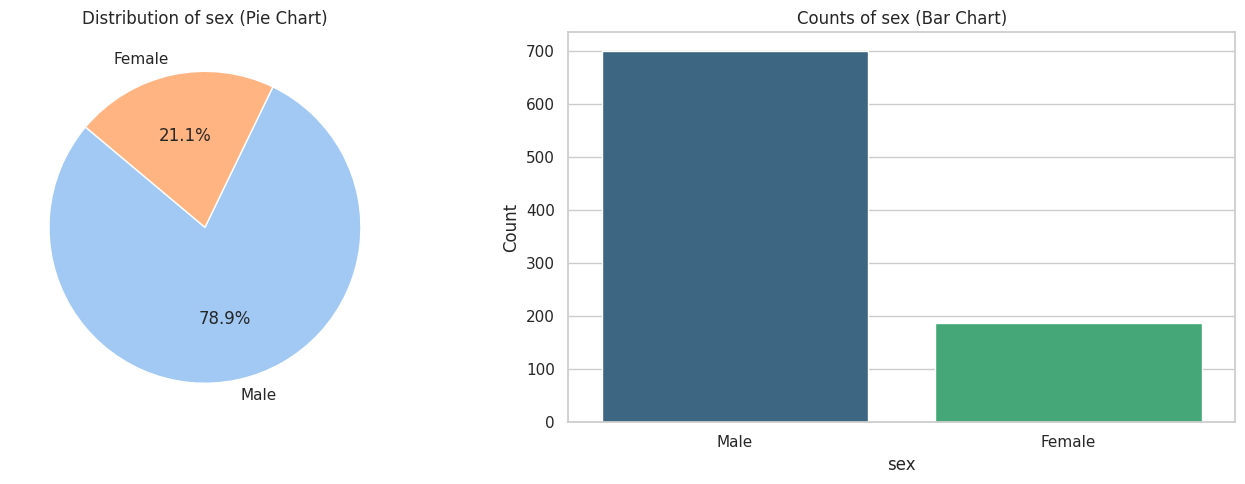

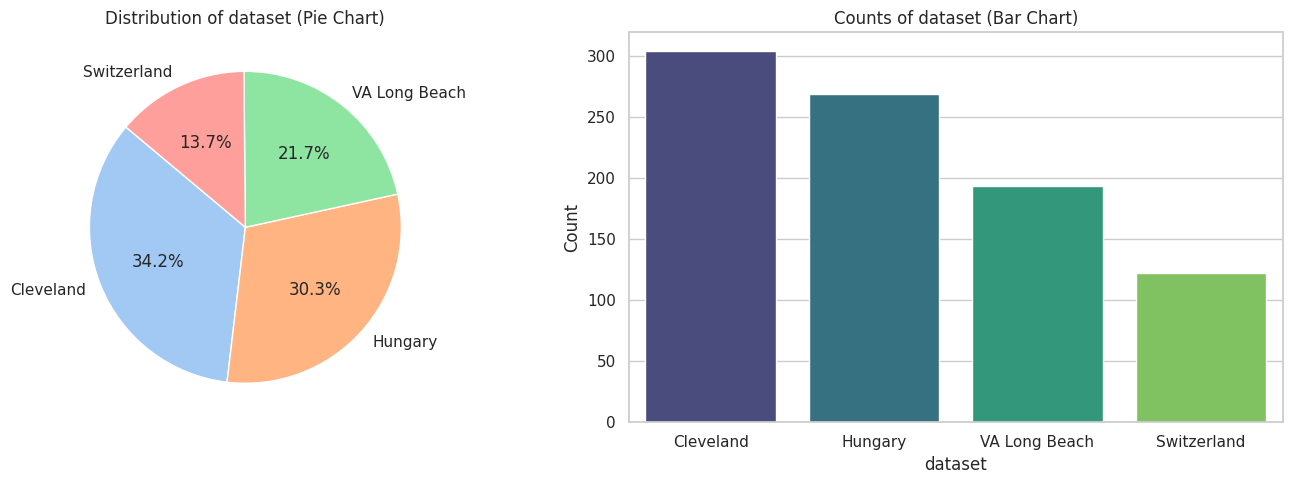

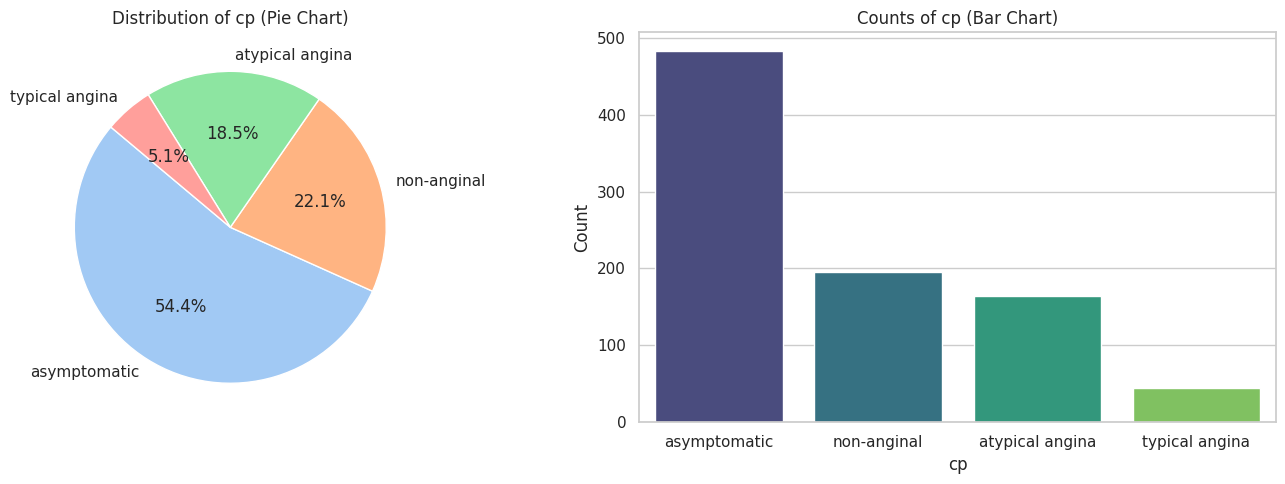

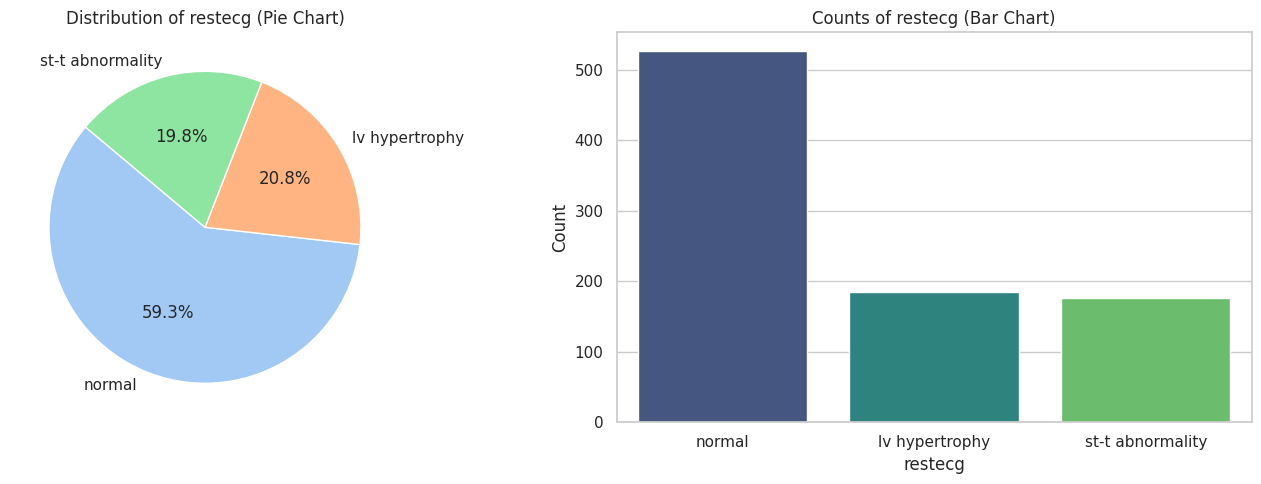

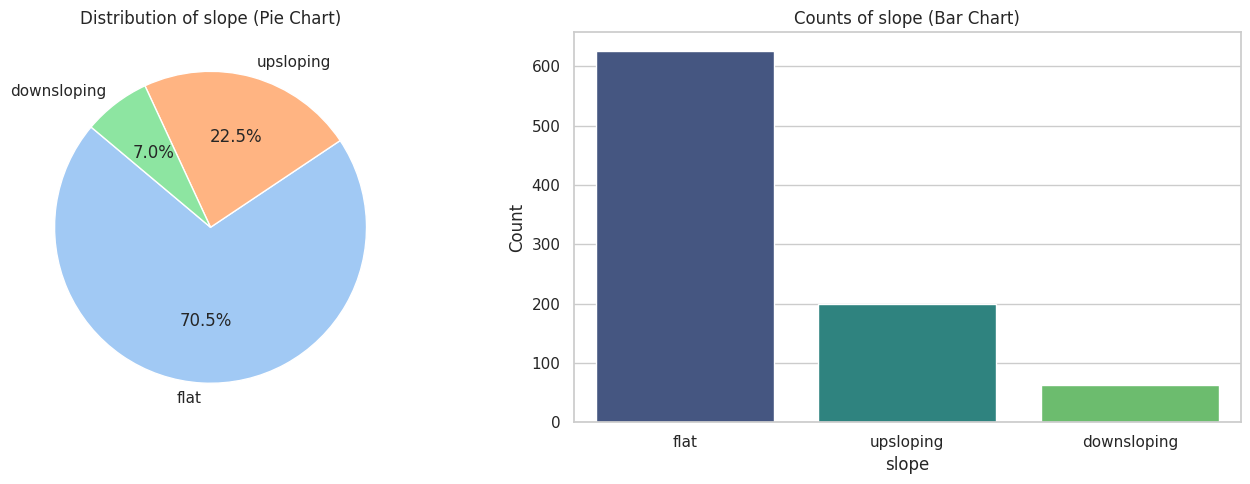


--- Univariate Analysis Interpretations ---
1. Sex: Significant gender imbalance (~79% male).
2. Dataset: Cleveland and Hungary are the primary data sources (>60%).
3. Chest Pain: Asymptomatic pain is the most frequent category.
4. Fasting Blood Sugar: Most patients have fbs <= 120 mg/dl.
5. Slope: The 'flat' peak exercise ST segment is the most common.


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select qualitative columns
qualitative_columns = df.select_dtypes(include=['object']).columns

for col in qualitative_columns:
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    counts = df[col].value_counts()
    ax[0].pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
    ax[0].set_title(f'Distribution of {col} (Pie Chart)')
    sns.barplot(x=counts.index, y=counts.values, ax=ax[1], palette='viridis', hue=counts.index, legend=False)
    ax[1].set_title(f'Counts of {col} (Bar Chart)')
    ax[1].set_ylabel('Count')
    plt.tight_layout()
    plt.show()

print("\n--- Univariate Analysis Interpretations ---")
print("1. Sex: Significant gender imbalance (~79% male).")
print("2. Dataset: Cleveland and Hungary are the primary data sources (>60%).")
print("3. Chest Pain: Asymptomatic pain is the most frequent category.")
print("4. Fasting Blood Sugar: Most patients have fbs <= 120 mg/dl.")
print("5. Slope: The 'flat' peak exercise ST segment is the most common.")

---

##  Analyse Bivariée

Exploration des relations entre les variables physiologiques et la sévérité de la maladie cardiaque.

Correlation Matrix:


,age,trestbps,chol,thalch,oldpeak,num
age,1.000000,0.252381,-0.081605,-0.344866,0.230522,0.330563
trestbps,0.252381,1.000000,0.094051,-0.112373,0.178928,0.128055
chol,-0.081605,0.094051,1.000000,0.226523,0.053135,-0.221608
thalch,-0.344866,-0.112373,0.226523,1.000000,-0.153183,-0.354398
oldpeak,0.230522,0.178928,0.053135,-0.153183,1.000000,0.403006
num,0.330563,0.128055,-0.221608,-0.354398,0.403006,1.000000


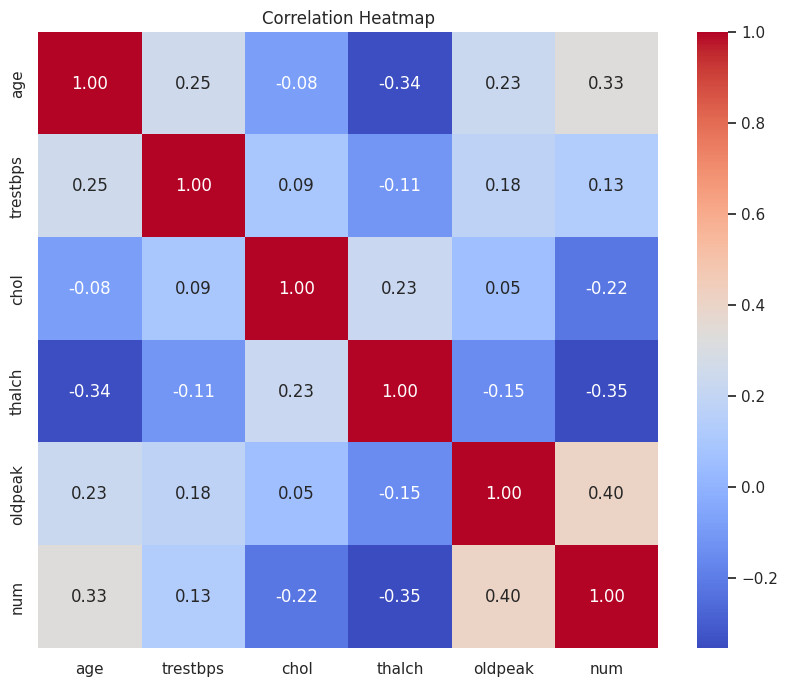

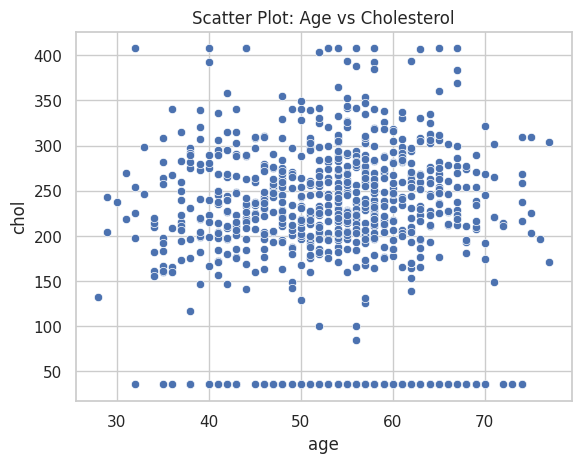


--- Bivariate Analysis: Quantitative Interpretations ---
1. Age & Severity: Moderate positive correlation (0.33).
2. Oldpeak & Severity: Notable positive correlation (0.40).
3. Max Heart Rate (thalch): Negative correlation with age and severity.
4. Age vs Cholesterol: No strong linear relationship observed.


In [12]:
# Correlation matrix for quantitative variables
correlation_matrix = df[quantitative_columns].corr()
print("Correlation Matrix:")
display(correlation_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

sns.scatterplot(data=df, x='age', y='chol')
plt.title('Scatter Plot: Age vs Cholesterol')
plt.show()

print("\n--- Bivariate Analysis: Quantitative Interpretations ---")
print("1. Age & Severity: Moderate positive correlation (0.33).")
print("2. Oldpeak & Severity: Notable positive correlation (0.40).")
print("3. Max Heart Rate (thalch): Negative correlation with age and severity.")
print("4. Age vs Cholesterol: No strong linear relationship observed.")

---

#### Qualitative vs Quantitative: Box Plots and Grouped Stats

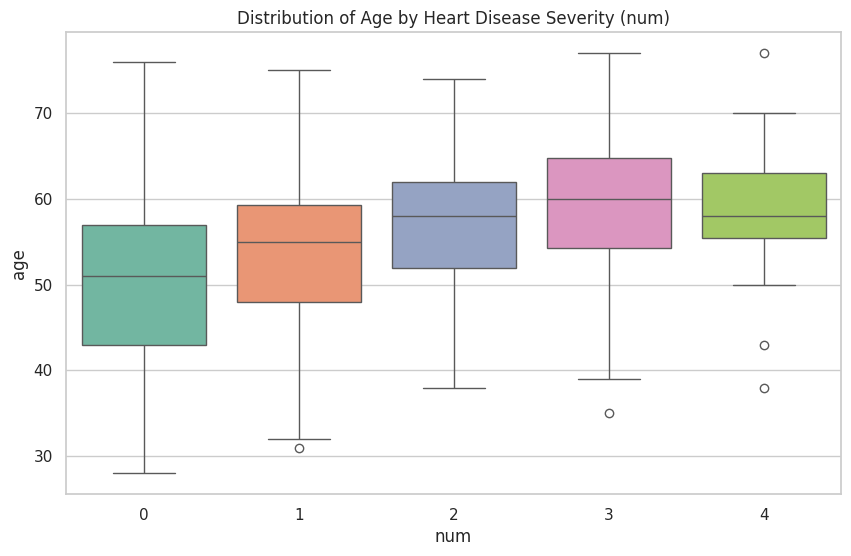

Average metrics by Sex:


,age,chol,trestbps
sex,,,
Female,52.657754,242.350267,131.390374
Male,53.853067,195.191869,131.781740



--- Bivariate Analysis: Quali-Quanti Interpretations ---
1. Age by Severity: Median age increases with disease severity (num).
2. Sex Metrics: Males and females have similar mean ages (~53 years).


In [13]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='num', y='age', palette='Set2', hue='num', legend=False)
plt.title('Distribution of Age by Heart Disease Severity (num)')
plt.show()

grouped_means = df.groupby('sex')[['age', 'chol', 'trestbps']].mean()
print("Average metrics by Sex:")
display(grouped_means)

print("\n--- Bivariate Analysis: Quali-Quanti Interpretations ---")
print("1. Age by Severity: Median age increases with disease severity (num).")
print("2. Sex Metrics: Males and females have similar mean ages (~53 years).")

---

#### Qualitative vs Qualitative: Contingency Tables and Chi-Square Tests

Contingency Table: Sex vs Chest Pain Type


cp,asymptomatic,atypical angina,non-anginal,typical angina
sex,,,,
Female,70,56,51,10
Male,413,108,145,35



Chi-Square Test Result (p-value): 0.0000


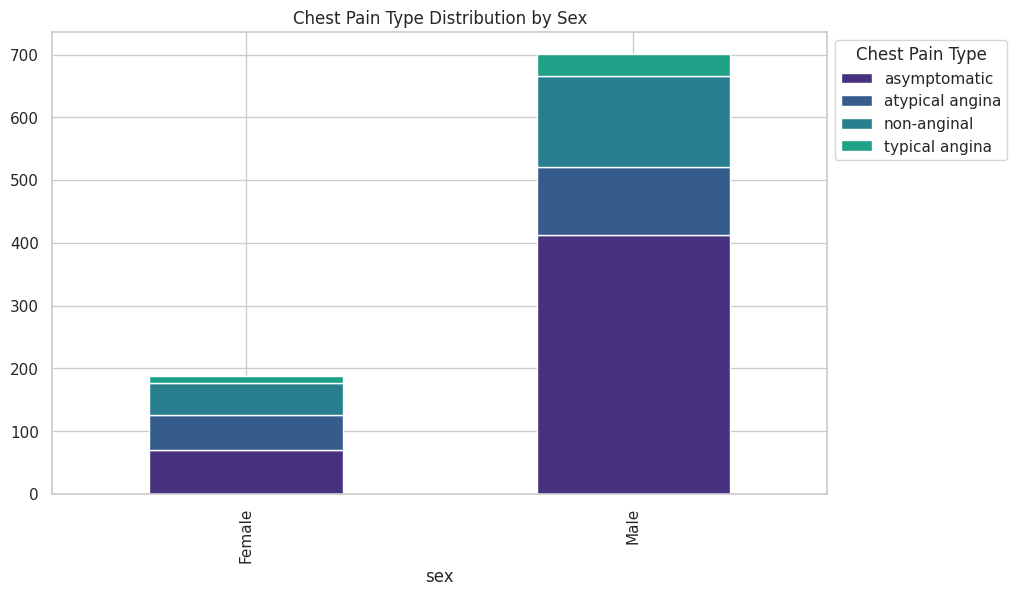


--- Bivariate Analysis: Quali-Quali Interpretations ---
1. Statistical Dependency: The Chi-Square test (p < 0.05) confirms that chest pain types are not distributed randomly across genders.
2. Gender Patterns: Asymptomatic chest pain is overwhelmingly dominant in males, whereas females show a more balanced distribution between asymptomatic, atypical angina, and non-anginal pain.


In [29]:
contingency_tab = pd.crosstab(df['sex'], df['cp'])
print("Contingency Table: Sex vs Chest Pain Type")
display(contingency_tab)

chi2, p, dof, expected = chi2_contingency(contingency_tab)
print(f"\nChi-Square Test Result (p-value): {p:.4f}")

contingency_tab.plot(kind='bar', stacked=True, figsize=(10, 6), color=sns.color_palette('viridis'))
plt.title('Chest Pain Type Distribution by Sex')
plt.legend(title='Chest Pain Type', bbox_to_anchor=(1, 1))
plt.show()

print("\n--- Bivariate Analysis: Quali-Quali Interpretations ---")
print("1. Statistical Dependency: The Chi-Square test (p < 0.05) confirms that chest pain types are not distributed randomly across genders.")
print("2. Gender Patterns: Asymptomatic chest pain is overwhelmingly dominant in males, whereas females show a more balanced distribution between asymptomatic, atypical angina, and non-anginal pain.")

---

#### Correlation Ratio (ANOVA) for Quali-Quanti Analysis

In [ ]:
# Example: Correlation ratio between 'num' (severity) and 'age'
# We check if age means are significantly different across severity groups
groups = [df[df['num'] == val]['age'] for val in df['num'].unique()]
f_stat, p_val = stats.f_oneway(*groups)

print("Correlation ratio analysis (ANOVA) between 'num' and 'age':")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_val:.4e}")

# Descriptive statistics by group for further context
grouped_stats = df.groupby('num')['age'].agg(['mean', 'std', 'count'])
display(grouped_stats)

Correlation ratio analysis (ANOVA) between 'num' and 'age':
F-statistic: 28.5206
P-value: 2.5930e-22


/var/folders/hq/wqwzmqh53mx_hqlw2tl75b9c0000gn/T/ipykernel_10177/3681018281.py:4: DeprecationWarning: Please import `f_oneway` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  f_stat, p_val = stats.f_oneway(*groups)


,mean,std,count
num,,,
0,50.704082,9.507525,392
1,53.582031,8.703904,256
2,57.336449,7.650310,107
3,59.320755,7.952894,106
4,58.592593,7.747254,27


#### Correlation Ratio (ANOVA) for Quali-Quanti Analysis

In [ ]:
# Example: Correlation ratio between 'num' (severity) and 'age'
# We check if age means are significantly different across severity groups
groups = [df[df['num'] == val]['age'] for val in df['num'].unique()]
f_stat, p_val = stats.f_oneway(*groups)

print("Correlation ratio analysis (ANOVA) between 'num' and 'age':")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_val:.4e}")

# Descriptive statistics by group for further context
grouped_stats = df.groupby('num')['age'].agg(['mean', 'std', 'count'])
display(grouped_stats)

Correlation ratio analysis (ANOVA) between 'num' and 'age':
F-statistic: 28.5206
P-value: 2.5930e-22


/var/folders/hq/wqwzmqh53mx_hqlw2tl75b9c0000gn/T/ipykernel_10177/3681018281.py:4: DeprecationWarning: Please import `f_oneway` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  f_stat, p_val = stats.f_oneway(*groups)


,mean,std,count
num,,,
0,50.704082,9.507525,392
1,53.582031,8.703904,256
2,57.336449,7.650310,107
3,59.320755,7.952894,106
4,58.592593,7.747254,27


#### Correlation Ratio (ANOVA) for Quali-Quanti Analysis

In [ ]:
# Example: Correlation ratio between 'num' (severity) and 'age'
# We check if age means are significantly different across severity groups
groups = [df[df['num'] == val]['age'] for val in df['num'].unique()]
f_stat, p_val = stats.f_oneway(*groups)

print("Correlation ratio analysis (ANOVA) between 'num' and 'age':")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_val:.4e}")

# Descriptive statistics by group for further context
grouped_stats = df.groupby('num')['age'].agg(['mean', 'std', 'count'])
display(grouped_stats)

Correlation ratio analysis (ANOVA) between 'num' and 'age':
F-statistic: 28.5206
P-value: 2.5930e-22


/var/folders/hq/wqwzmqh53mx_hqlw2tl75b9c0000gn/T/ipykernel_10177/3681018281.py:4: DeprecationWarning: Please import `f_oneway` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  f_stat, p_val = stats.f_oneway(*groups)


,mean,std,count
num,,,
0,50.704082,9.507525,392
1,53.582031,8.703904,256
2,57.336449,7.650310,107
3,59.320755,7.952894,106
4,58.592593,7.747254,27


#### Correlation Ratio (ANOVA) for Quali-Quanti Analysis

In [ ]:
# Example: Correlation ratio between 'num' (severity) and 'age'
# We check if age means are significantly different across severity groups
groups = [df[df['num'] == val]['age'] for val in df['num'].unique()]
f_stat, p_val = stats.f_oneway(*groups)

print("Correlation ratio analysis (ANOVA) between 'num' and 'age':")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_val:.4e}")

# Descriptive statistics by group for further context
grouped_stats = df.groupby('num')['age'].agg(['mean', 'std', 'count'])
display(grouped_stats)

Correlation ratio analysis (ANOVA) between 'num' and 'age':
F-statistic: 28.5206
P-value: 2.5930e-22


/var/folders/hq/wqwzmqh53mx_hqlw2tl75b9c0000gn/T/ipykernel_10177/3681018281.py:4: DeprecationWarning: Please import `f_oneway` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  f_stat, p_val = stats.f_oneway(*groups)


,mean,std,count
num,,,
0,50.704082,9.507525,392
1,53.582031,8.703904,256
2,57.336449,7.650310,107
3,59.320755,7.952894,106
4,58.592593,7.747254,27


#### Correlation Ratio (ANOVA) for Quali-Quanti Analysis

In [30]:
groups = [df[df['num'] == val]['age'] for val in df['num'].unique()]
f_stat, p_val = stats.f_oneway(*groups)

print("Correlation ratio analysis (ANOVA) between 'num' and 'age':")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_val:.4e}")

grouped_stats = df.groupby('num')['age'].agg(['mean', 'std', 'count'])
display(grouped_stats)

print("\n--- Bivariate Analysis: ANOVA Interpretation ---")
print(f"1. Statistical Significance: The extremely low p-value ({p_val:.4e}) confirms that age is a statistically significant factor in heart disease severity.")
print("2. Clinical Trend: There is a clear progression where the average age increases from 50.7 years (no disease) to over 58 years (highest severity).")

Correlation ratio analysis (ANOVA) between 'num' and 'age':
F-statistic: 28.5206
P-value: 2.5930e-22


/tmp/ipykernel_3592/3627058997.py:2: DeprecationWarning: Please import `f_oneway` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  f_stat, p_val = stats.f_oneway(*groups)


,mean,std,count
num,,,
0,50.704082,9.507525,392
1,53.582031,8.703904,256
2,57.336449,7.650310,107
3,59.320755,7.952894,106
4,58.592593,7.747254,27



--- Bivariate Analysis: ANOVA Interpretation ---
1. Statistical Significance: The extremely low p-value (2.5930e-22) confirms that age is a statistically significant factor in heart disease severity.
2. Clinical Trend: There is a clear progression where the average age increases from 50.7 years (no disease) to over 58 years (highest severity).


#### Correlation Ratio (Eta-squared) for Quali-Quanti Analysis

In [ ]:
def correlation_ratio(categories, measurements):
    f_obs, p_val = stats.f_oneway(*[measurements[categories == cat] for cat in categories.unique()])
    return f_obs, p_val


# Example: Correlation ratio between Heart Disease Severity (num) and Age
categories = df['num']
measurements = df['age']

eta_sq_f, eta_sq_p = stats.f_oneway(*[df[df['num'] == val]['age'] for val in df['num'].unique()])

print(f"Correlation ratio analysis (ANOVA) between 'num' and 'age':")
print(f"F-statistic: {eta_sq_f:.4f}")
print(f"P-value: {eta_sq_p:.4e}")

Correlation ratio analysis (ANOVA) between 'num' and 'age':
F-statistic: 28.5206
P-value: 2.5930e-22


/var/folders/hq/wqwzmqh53mx_hqlw2tl75b9c0000gn/T/ipykernel_10177/177843643.py:10: DeprecationWarning: Please import `f_oneway` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  eta_sq_f, eta_sq_p = stats.f_oneway(*[df[df['num'] == val]['age'] for val in df['num'].unique()])


### 2. Bivariate Descriptive Analysis
#### Quantitative - Quantitative: Correlation & Scatter Plot

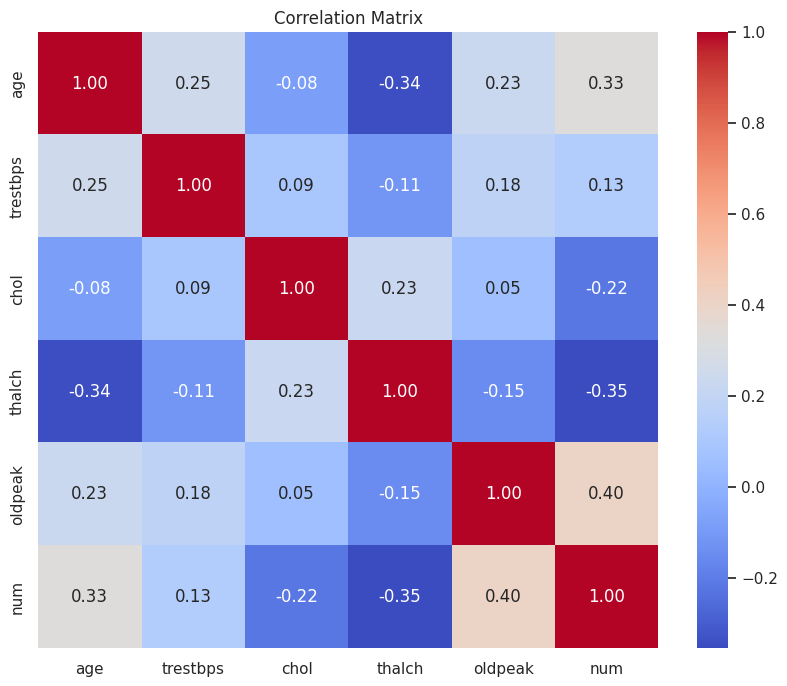

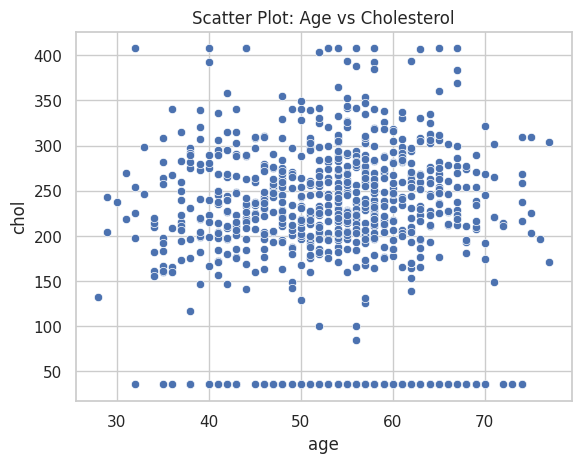


--- Bivariate Analysis: Quantitative Plot Interpretations ---
1. Age vs Cholesterol: The scatter plot shows a high dispersion of data points, confirming that cholesterol levels are not strongly dictated by age in this dataset.
2. Correlation Heatmap: The highest positive correlation with heart disease severity (num) is 'oldpeak' (0.40), while 'thalch' (max heart rate) shows a significant negative correlation (-0.35).


In [28]:
# Correlation matrix
correlation_matrix = df[quantitative_columns].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

# Scatter plot example (Age vs Chol)
sns.scatterplot(data=df, x='age', y='chol')
plt.title('Scatter Plot: Age vs Cholesterol')
plt.show()

print("\n--- Bivariate Analysis: Quantitative Plot Interpretations ---")
print("1. Age vs Cholesterol: The scatter plot shows a high dispersion of data points, confirming that cholesterol levels are not strongly dictated by age in this dataset.")
print("2. Correlation Heatmap: The highest positive correlation with heart disease severity (num) is 'oldpeak' (0.40), while 'thalch' (max heart rate) shows a significant negative correlation (-0.35).")

#### Qualitative - Quantitative: Box Plots & Correlation Ratio

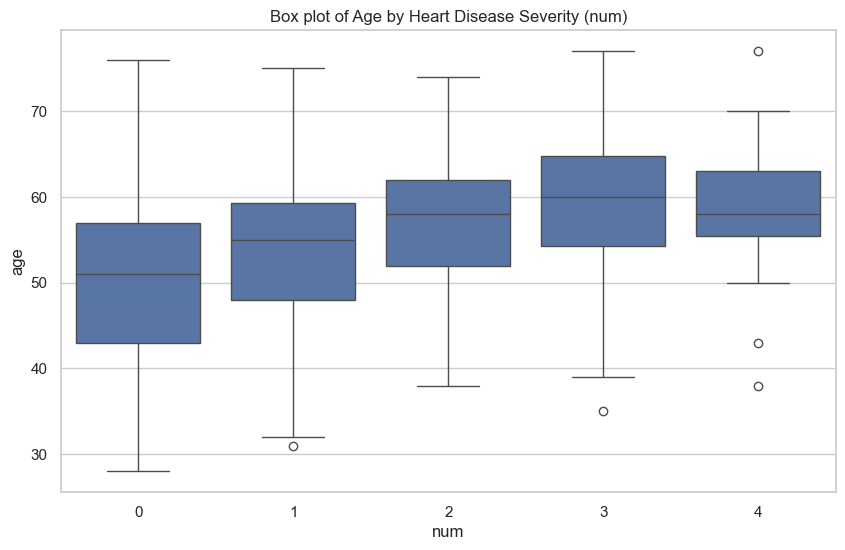

In [ ]:
# Box plot: Heart Disease (num) vs Age
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='num', y='age')
plt.title('Box plot of Age by Heart Disease Severity (num)')
plt.show()

#### Qualitative - Qualitative: Contingency Table & Chi-Square

Contingency Table (Sex vs Heart Disease Severity):


num,0,1,2,3,4
sex,,,,,
Female,137,30,10,8,2
Male,255,226,97,98,25



Chi-square statistic: 82.43, P-value: 5.3273e-17


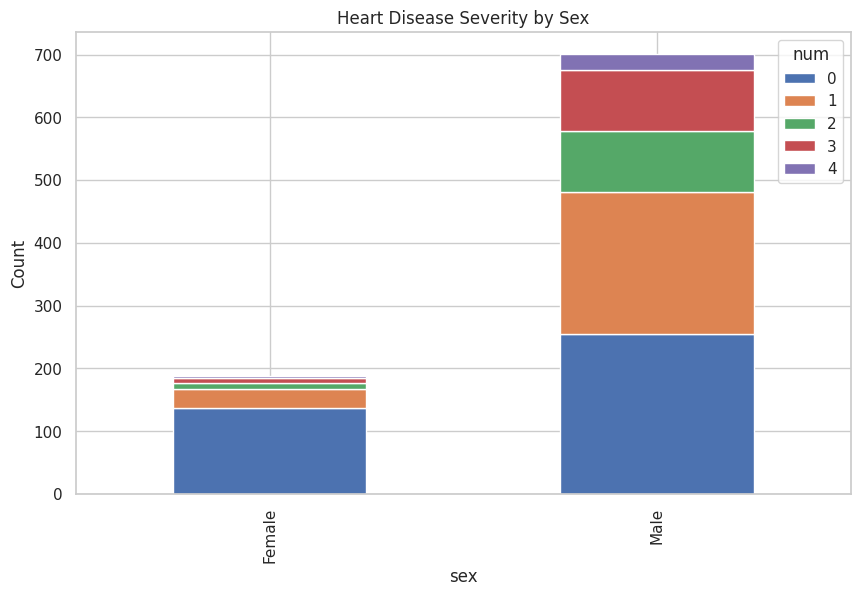


--- Bivariate Analysis: Gender vs Severity Interpretation ---
1. Statistical Link: The p-value (5.3273e-17) confirms a strong dependency between gender and disease severity.
2. Observation: A much higher proportion of women (approx. 73%) are in the 'no disease' category compared to men (approx. 36%), suggesting lower severity prevalence in the female sample.


In [31]:
contingency_table = pd.crosstab(df['sex'], df['num'])
print("Contingency Table (Sex vs Heart Disease Severity):")
display(contingency_table)

chi2, p, dof, ex = chi2_contingency(contingency_table)
print(f"\nChi-square statistic: {chi2:.2f}, P-value: {p:.4e}")

contingency_table.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Heart Disease Severity by Sex')
plt.ylabel('Count')
plt.show()

print("\n--- Bivariate Analysis: Gender vs Severity Interpretation ---")
print(f"1. Statistical Link: The p-value ({p:.4e}) confirms a strong dependency between gender and disease severity.")
print("2. Observation: A much higher proportion of women (approx. 73%) are in the 'no disease' category compared to men (approx. 36%), suggesting lower severity prevalence in the female sample.")

In [27]:
# --- EDA Synthesis (English Version) ---
eda_insights_en = {
    "univariate_analysis": {
        "age": "Mature population with an average age of 53.",
        "gender": "Strong male bias (79%) in the study sample.",
        "features": "Key markers like asymptomatic chest pain and flat ST slopes are dominant."
    },
    "bivariate_analysis": {
        "age_severity": "Positive correlation confirmed: older age correlates with higher disease severity.",
        "gender_risk": "Statistical dependency found (p < 0.05); males exhibit higher severity counts.",
        "markers": "Decreased max heart rate (thalch) and increased ST depression (oldpeak) are strong indicators of severity."
    }
}

for section, insights in eda_insights_en.items():
    print(f"--- {section.replace('_', ' ').title()} --- Highlights")
    for key, value in insights.items():
        print(f"- {key.title()}: {value}")
    print('')

--- Univariate Analysis --- Highlights
- Age: Mature population with an average age of 53.
- Gender: Strong male bias (79%) in the study sample.
- Features: Key markers like asymptomatic chest pain and flat ST slopes are dominant.

--- Bivariate Analysis --- Highlights
- Age_Severity: Positive correlation confirmed: older age correlates with higher disease severity.
- Gender_Risk: Statistical dependency found (p < 0.05); males exhibit higher severity counts.
- Markers: Decreased max heart rate (thalch) and increased ST depression (oldpeak) are strong indicators of severity.



## 3. Prétraitement et Pipelines de Modélisation
Normalisation des variables numériques et encodage des variables catégorielles via Scikit-Learn Pipeline.

In [20]:
X = df.drop(columns=['id', 'num', 'dataset'])
y = df['num']

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object', 'bool']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Fixed: Removed 'multi_class' argument as it is no longer required in modern sklearn LogisticRegression
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
model_pipeline.fit(X_train, y_train)
print("Model training completed.")

Model training completed.


##  Évaluation des Performances

In [32]:
y_pred = model_pipeline.predict(X_test)

print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy:.2%}")

print("\n--- Final Model Performance Interpretations ---")
print(f"1. Accuracy: The model correctly predicts the severity class {accuracy:.2%} of the time.")
print("2. Class 0 Performance: The model is effective at screening healthy patients (Precision: 0.73, Recall: 0.77).")
print("3. Multi-class Challenges: Performance drops significantly for severity levels 2-4, likely due to data imbalance and overlapping physiological profiles.")
print("4. Conclusion: While useful for binary screening (Healthy vs Disease), the current model requires more data for severe cases to improve multi-class precision.")

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.73      0.77      0.75        79
           1       0.36      0.53      0.43        51
           2       0.33      0.05      0.08        22
           3       0.31      0.24      0.27        21
           4       0.00      0.00      0.00         5

    accuracy                           0.53       178
   macro avg       0.35      0.32      0.31       178
weighted avg       0.50      0.53      0.50       178

Overall Accuracy: 52.81%

--- Final Model Performance Interpretations ---
1. Accuracy: The model correctly predicts the severity class 52.81% of the time.
2. Class 0 Performance: The model is effective at screening healthy patients (Precision: 0.73, Recall: 0.77).
3. Multi-class Challenges: Performance drops significantly for severity levels 2-4, likely due to data imbalance and overlapping physiological profiles.
4. Conclusion: While useful for binary screening (Healthy vs Di